# Generación de Campos Aleatorios de Conductividad Hidráulica en Acuíferos 3D

**Método espectral de incrustación circulante** — implementación en Python basada en el toolbox MATLAB de Wolfgang Nowak (IWS, Universidad de Stuttgart).

---

## ¿Qué genera este notebook?

Este notebook genera realizaciones estocásticas del campo de **conductividad hidráulica** $K(\mathbf{x})$ en un acuífero tridimensional. Cada realización es un posible "escenario geológico" del subsuelo, estadísticamente consistente con los parámetros geoestadísticos especificados (variograma, varianza, longitudes de correlación).

Los campos generados pueden usarse directamente como entrada para:
- Modelos de flujo en aguas subterráneas (MODFLOW, FEFLOW, FEniCS)
- Simulaciones de transporte de contaminantes
- Análisis de incertidumbre y análisis de sensibilidad
- Optimización robusta de sistemas de remediación

---

## ¿Por qué trabajar con ln(K) y no con K directamente?

La conductividad hidráulica $K$ en acuíferos naturales varía varios órdenes de magnitud (p.ej. $10^{-10}$ a $10^{-2}$ m/s) y su distribución es marcadamente asimétrica. Se ha demostrado empíricamente que el **logaritmo natural** $Y = \ln(K)$ sigue aproximadamente una distribución **normal (Gaussiana)**, lo que permite aplicar la geoestadística lineal estándar.

La relación entre ambas variables es:

$$K(\mathbf{x}) = \exp\bigl(Y(\mathbf{x})\bigr), \qquad Y(\mathbf{x}) = \ln K(\mathbf{x})$$

La media geométrica de $K$ —que controla el flujo promedio en un acuífero homogéneo equivalente— es:

$$K_\text{geom} = \exp(\mu_Y), \qquad \text{donde } \mu_Y = \mathbb{E}[Y]$$

> **Referencia:** Freeze, R.A. (1975). A stochastic-conceptual analysis of one-dimensional groundwater flow in nonuniform homogeneous media. *Water Resour. Res.*, 11(5):725–741.

---

## Metodología: método espectral de incrustación circulante

El método fue formalizado por **Dietrich & Newsam (1993, 1997)** y es el más eficiente para generar campos aleatorios multi-Gaussianos en dominios regulares. La idea central es explotar la estructura **Toeplitz circulante** de la matriz de covarianza de un campo estacionario para diagonalizarla mediante la **Transformada de Fourier Discreta (FFT)**.

### Fundamento matemático

Dado un campo aleatorio estacionario $Y(\mathbf{x})$ con función de covarianza $C(\mathbf{h}) = \text{Cov}[Y(\mathbf{x}), Y(\mathbf{x}+\mathbf{h})]$, se desea generar una realización $\mathbf{y}$ tal que:

$$\mathbf{y} \sim \mathcal{N}(\mu_Y \mathbf{1},\; \mathbf{Q})$$

donde $\mathbf{Q}_{ij} = C(\mathbf{x}_i - \mathbf{x}_j)$ es la matriz de covarianza, de tamaño $N \times N$ (potencialmente muy grande).

La factorización directa $\mathbf{Q} = \mathbf{L}\mathbf{L}^\top$ (Cholesky) requiere $\mathcal{O}(N^3)$ operaciones — impracticable para grillas 3D. El método espectral lo reduce a $\mathcal{O}(N \log N)$.

### Algoritmo paso a paso

**Paso 1 — Incrustación circulante (Embedding):**  
Se amplía el dominio original $\Omega$ a un dominio mayor $\tilde{\Omega}$ de forma que la submatriz de covarianza incrustada sea **circulante y definida positiva**. El tamaño de incrustación se elige heurísticamente para que la covarianza decaiga a valores despreciables en los bordes del dominio ampliado. Esta es la contribución clave de Nowak et al. (2003) respecto a implementaciones anteriores.

**Paso 2 — Eigenvalores vía FFT:**  
Para una matriz circulante, los eigenvalores son exactamente los coeficientes de la FFT del primer renglón:

$$\boldsymbol{\lambda} = \text{FFT}(\mathbf{q}_0), \qquad \mathbf{q}_0 = [C(0),\, C(\Delta x),\, C(2\Delta x),\, \ldots]$$

**Paso 3 — Generación del campo (Dietrich & Newsam):**  
Se genera ruido complejo Gaussiano $\boldsymbol{\varepsilon} \sim \mathcal{CN}(\mathbf{0}, \mathbf{I})$ y se aplica:

$$\tilde{\mathbf{Y}} = \text{Re}\!\left[\text{IFFT}\!\left(\sqrt{\boldsymbol{\lambda}/\tilde{N}}\; \odot\; \boldsymbol{\varepsilon}\right)\right] \cdot \tilde{N}$$

donde $\tilde{N}$ es el número de puntos del dominio ampliado y $\odot$ es el producto elemento a elemento.

**Paso 4 — Extracción:**  
Se extrae el subcampo correspondiente al dominio original $\Omega$ y se suma la media $\mu_Y$.

> La FFT de la covarianza (`FFTQe`) solo necesita calcularse **una vez** y puede reutilizarse para generar todas las realizaciones del ensemble, lo que hace al método muy eficiente.

---

## Estructura del notebook

| Sección | Contenido |
|---------|-----------|
| **1. Parámetros** | Todas las variables configurables en un solo bloque |
| **2. Variograma teórico** | Gráfica de la función de covarianza y semivariograma |
| **3. Una realización** | Cortes horizontales y verticales de ln(K) y K |
| **4. Ensemble** | N realizaciones con escala de color común |
| **5. Estadísticas** | Media y varianza espaciales del ensemble |
| **6. Guardado** | Exportar N realizaciones a formato `.npz` |

---

## Referencias

1. **Dietrich, C.R. & Newsam, G.N. (1993).** A fast and exact method for multidimensional Gaussian stochastic simulations. *Water Resources Research*, 29(8):2861–2869. https://doi.org/10.1029/93WR01070

2. **Dietrich, C.R. & Newsam, G.N. (1997).** Fast and exact simulation of stationary Gaussian processes through circulant embedding of the covariance matrix. *SIAM Journal on Scientific Computing*, 18(4):1088–1107. https://doi.org/10.1137/S1064827592240555

3. **Nowak, W., Tenkleve, S. & Cirpka, O.A. (2003).** Efficient computation of linearized cross-covariance and auto-covariance matrices of interdependent quantities. *Mathematical Geology*, 35(1):53–66. https://doi.org/10.1023/A:1022365112368

4. **Kitanidis, P.K. (1997).** *Introduction to Geostatistics: Applications in Hydrogeology*. Cambridge University Press, Cambridge. ISBN: 978-0521587471

5. **Zinn, B. & Harvey, C.F. (2003).** When good statistical models of aquifer heterogeneity go bad: a comparison of flow, dispersion, and mass transfer in connected and multivariate Gaussian hydraulic conductivity fields. *Water Resources Research*, 39(3):1051. https://doi.org/10.1029/2001WR001146

6. **Freeze, R.A. (1975).** A stochastic-conceptual analysis of one-dimensional groundwater flow in nonuniform homogeneous media. *Water Resources Research*, 11(5):725–741. https://doi.org/10.1029/WR011i005p00725

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('.').resolve()))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import scipy.special as sp

from modules.config_structs import Grid, Model
from modules.generate_randomfield import initialize_FFT_cov, generate_randomfield

print('Módulos cargados correctamente.')

Módulos cargados correctamente.


---
## 1. Parámetros de entrada

Esta es la **única celda que necesitas modificar** para adaptar el notebook a tu caso de estudio. Los parámetros están organizados en grupos temáticos.

### 1.1 Discretización del dominio

| Parámetro | Descripción | Unidad |
|-----------|-------------|--------|
| `n_pts_y`, `n_pts_x`, `n_pts_z` | Número de nodos en cada dirección | — |
| `d_pts_y`, `d_pts_x`, `d_pts_z` | Tamaño de celda en cada dirección | m |

> El dominio total es `Ly = n_pts_y × d_pts_y` metros en cada dirección. Para acuíferos reales, `d_pts_z` suele ser menor que `d_pts_x/y` porque la estratificación vertical ocurre a escalas más finas.

### 1.2 Estadísticas de ln(K)

| Parámetro | Descripción | Valores típicos |
|-----------|-------------|-----------------|
| `lnK_mean` (μ_Y) | Media del campo ln(K) | −10 a −2 ln(m/s) |
| `lnK_variance` (σ²_Y) | Varianza del campo ln(K) | 0.1 (homogéneo) a 5 (muy heterogéneo) |

La media geométrica de K es `K_geom = exp(lnK_mean)`. Por ejemplo: μ_Y = −4 → K_geom ≈ 0.018 m/s (arena gruesa).

### 1.3 Modelo de variograma

El **variograma** describe cómo decrece la similitud entre dos puntos al aumentar su separación. Se eligen dos modelos:

- **`'matern'`** (recomendado): familia flexible controlada por el parámetro κ. Incluye el modelo exponencial (κ=0.5) como caso particular. Es el más adecuado para ln(K) en hidrogeología.
- **`'gaussian'`**: correlación que cae muy suavemente. Produce campos excesivamente suaves, poco realistas para medios porosos naturales.

### 1.4 Longitudes de correlación λ

La **longitud de correlación** $\lambda$ (también llamada *integral scale* o *range*) indica la distancia a la cual la covarianza ha decaído significativamente. Puntos más cercanos que λ son similares entre sí; puntos más lejanos son estadísticamente independientes.

En acuíferos aluviales es típico que:
- λ_horizontal >> λ_vertical (anisotropía debida a la estratificación sedimentaria)
- Razón de anisotropía: λ_x/λ_z ≈ 10 a 100

### 1.5 Parámetro de suavidad Matérn κ

El parámetro κ controla la **regularidad** (suavidad) del campo:

| κ | Comportamiento | Uso típico |
|---|----------------|------------|
| 0.5 | Exponencial — continuo pero no diferenciable | ln(K) en acuíferos (más realista) |
| 1.5 | Diferenciable una vez | Transición |
| 2.5 | Diferenciable dos veces | Campos más suaves |
| ∞ | Equivalente al modelo Gaussiano | Máxima suavidad |

### 1.6 Conectividad Zinn & Harvey

La transformación de **Zinn & Harvey (2003)** modifica el campo multi-Gaussiano estándar para crear conectividad preferencial, más representativa de acuíferos reales con canales o lentes:

- `flag_zh = 0`: campo multi-Gaussiano estándar
- `flag_zh = 1`: alta K en canales conectados (baja K dispersa)
- `flag_zh = 2`: baja K en canales conectados (alta K dispersa)

In [2]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║              PARÁMETROS DE ENTRADA — modifica aquí                         ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# ── Discretización del dominio 3D ─────────────────────────────────────────────
n_pts_y  = 60         # nodos en dirección y  (horizontal)
n_pts_x  = 60         # nodos en dirección x  (horizontal)
n_pts_z  = 20         # nodos en dirección z  (vertical / profundidad)
d_pts_y  = 5.0        # espaciado en y  [m]
d_pts_x  = 5.0        # espaciado en x  [m]
d_pts_z  = 2.0        # espaciado en z  [m]  (capas más delgadas en la vertical)

# ── Estadísticas de ln(K) ─────────────────────────────────────────────────────
lnK_mean     = -4.0   # media  μ_Y = ln(K_geom)  [ln(m/s)]
lnK_variance = 1.0    # varianza σ²_Y  (σ²_Y = 1 → heterogeneidad moderada)

# ── Modelo de variograma ───────────────────────────────────────────────────────
# Opciones: 'matern'   (recomendado, más flexible)
#           'gaussian' (infinitamente derivable, puede ser irreal para K)
variogram_name = 'matern'

# ── Longitudes de correlación [m] — anisotropía 3D ───────────────────────────
# Típico en acuíferos: λ_horizontal >> λ_vertical  (estratificación)
lambda_y = 30.0       # correlación en y  [m]
lambda_x = 60.0       # correlación en x  [m]  (mayor en la dirección del flujo)
lambda_z = 5.0        # correlación vertical [m]  (mucho menor → estratificado)

# ── Parámetro de suavidad Matérn κ ────────────────────────────────────────────
# κ = 0.5  → exponencial (menos suave, más realista para ln K)
# κ = 1.5  → una vez diferenciable
# κ = 2.5  → dos veces diferenciable
# κ → ∞   → equivalente a Gaussiano
kappa = 0.5

# ── Efectos adicionales ────────────────────────────────────────────────────────
nugget  = 0.0         # efecto nugget (relativo a σ²_Y); 0 = desactivado
micro   = 0.0         # parámetro microscala (Kitanidis 1997);   0 = desactivado

# ── Conectividad Zinn & Harvey (2003) ─────────────────────────────────────────
# flag_zh = 0 → campo estándar multi-Gaussiano  (default)
# flag_zh = 1 → inclusiones de K baja  (canales de alta K conectados)
# flag_zh = 2 → inclusiones de K alta  (canales de baja K conectados)
flag_zh     = 0
zh_smoother = 0.0     # regularización Z&H  (rango 0–0.25); solo si flag_zh > 0

# ── Ensemble ──────────────────────────────────────────────────────────────────
n_realizations = 6    # número de realizaciones a generar
seed           = 42   # semilla aleatoria (None = aleatoria)

# ── Resumen ───────────────────────────────────────────────────────────────────
Lx = n_pts_x * d_pts_x
Ly = n_pts_y * d_pts_y
Lz = n_pts_z * d_pts_z
print(f'Dominio  : {Ly:.0f} m × {Lx:.0f} m × {Lz:.0f} m')
print(f'          ({n_pts_y}×{n_pts_x}×{n_pts_z} nodos,  Δ={d_pts_y}×{d_pts_x}×{d_pts_z} m)')
print(f'Variograma : {variogram_name}  |  σ²_Y={lnK_variance}  |  κ={kappa}')
print(f'λ [m]      : y={lambda_y}  x={lambda_x}  z={lambda_z}  '
      f'→ anisotropía h/v = {lambda_x/lambda_z:.1f}')
print(f'μ_Y        : {lnK_mean:.2f}  →  K_geom ≈ {np.exp(lnK_mean):.2e} m/s')
print(f'Ensemble   : {n_realizations} realizaciones,  seed={seed}')

Dominio  : 300 m × 300 m × 40 m
          (60×60×20 nodos,  Δ=5.0×5.0×2.0 m)
Variograma : matern  |  σ²_Y=1.0  |  κ=0.5
λ [m]      : y=30.0  x=60.0  z=5.0  → anisotropía h/v = 12.0
μ_Y        : -4.00  →  K_geom ≈ 1.83e-02 m/s
Ensemble   : 6 realizaciones,  seed=42


In [3]:
# ── Construcción de las estructuras Grid y Model (3D) ─────────────────────────

grid = Grid(
    n_pts      = np.array([n_pts_y, n_pts_x, n_pts_z]),
    d_pts      = np.array([d_pts_y, d_pts_x, d_pts_z]),
    domain_len = np.array([Ly, Lx, Lz]),
    npts       = n_pts_y * n_pts_x * n_pts_z,
    nd         = 3,
)

model = Model(
    name        = variogram_name,
    variance    = lnK_variance,
    lambda_     = np.array([lambda_y, lambda_x, lambda_z]),
    kappa       = kappa,
    micro       = micro,
    nugget      = nugget,
    flag_zh     = flag_zh,
    zh_smoother = zh_smoother,
    beta        = lnK_mean,
    Qbb         = 0.0,
    periodicity = np.array([0, 0, 0]),
)

# Vectores de coordenadas (usados en todas las celdas de visualización)
# El campo generado tiene shape (ny, nx, nz)
y_vec = np.arange(n_pts_y) * d_pts_y
x_vec = np.arange(n_pts_x) * d_pts_x
z_vec = np.arange(n_pts_z) * d_pts_z

# Índices de profundidad para mostrar cortes
iz_top = 0
iz_mid = n_pts_z // 2
iz_bot = n_pts_z - 1

# Pre-calcular FFT de la covarianza (se reutiliza en todo el ensemble)
FFTQe = initialize_FFT_cov(model, grid)
print(f'Grid  : nd={grid.nd},  n_pts={grid.n_pts},  d_pts={grid.d_pts} m')
print(f'Model : {model.name},  σ²={model.variance},  λ={model.lambda_} m,  κ={model.kappa}')
print(f'FFTQe : shape={FFTQe.shape}  (grilla embebida para def. positiva)')


Grid  : nd=3,  n_pts=[60 60 20],  d_pts=[5. 5. 2.] m
Model : matern,  σ²=1.0,  λ=[30. 60.  5.] m,  κ=0.5
FFTQe : shape=(64, 64, 32)  (grilla embebida para def. positiva)


---
## 2. Variograma teórico

### ¿Qué es el variograma?

El **semivariograma** $\gamma(\mathbf{h})$ cuantifica la disimilitud promedio entre los valores de $Y$ en dos puntos separados por el vector $\mathbf{h}$:

$$\gamma(\mathbf{h}) = \frac{1}{2}\,\mathbb{E}\!\left[(Y(\mathbf{x}+\mathbf{h}) - Y(\mathbf{x}))^2\right]$$

Para un campo estacionario, se relaciona con la covarianza mediante:

$$\gamma(\mathbf{h}) = C(\mathbf{0}) - C(\mathbf{h}) = \sigma^2_Y - C(\mathbf{h})$$

El variograma tiene tres parámetros estructurales clave:

| Parámetro | Símbolo | Descripción |
|-----------|---------|-------------|
| **Sill** | $\sigma^2_Y$ | Varianza total — valor al que se estabiliza $\gamma$ a grandes distancias |
| **Range / Escala** | $\lambda$ | Distancia a la que la correlación se vuelve despreciable |
| **Nugget** | $\tau^2$ | Discontinuidad en $h=0$, representa variabilidad sub-malla o errores de medición |

### Modelos de covarianza implementados

**Modelo Matérn** (Matérn, 1960; recomendado para ln(K)):

$$C(h) = \sigma^2 \frac{1}{2^{\kappa-1}\,\Gamma(\kappa)} \left(\frac{\sqrt{2\kappa}\,h}{\lambda}\right)^\kappa K_\kappa\!\left(\frac{\sqrt{2\kappa}\,h}{\lambda}\right)$$

donde $K_\kappa$ es la función de Bessel modificada de segundo tipo y $\Gamma(\cdot)$ es la función gamma. El parámetro κ controla la diferenciabilidad del campo generado.

**Modelo Gaussiano:**

$$C(h) = \sigma^2 \exp\!\left(-\left(\frac{h}{\lambda}\right)^2\right)$$

### Anisotropía 3D

Para campos anisotrópicos, la distancia efectiva se calcula como:

$$h_\text{eff} = \sqrt{\left(\frac{h_y}{\lambda_y}\right)^2 + \left(\frac{h_x}{\lambda_x}\right)^2 + \left(\frac{h_z}{\lambda_z}\right)^2}$$

Las gráficas siguientes muestran la covarianza y el variograma en las direcciones $x$ e $y$ (la dirección $z$ con $\lambda_z \ll \lambda_x$ produce un rango mucho más corto, visible en la sección 6).

> **Referencia:** Matérn, B. (1960). *Spatial Variation*. Meddelanden från Statens Skogsforskningsinstitut, 49(5).

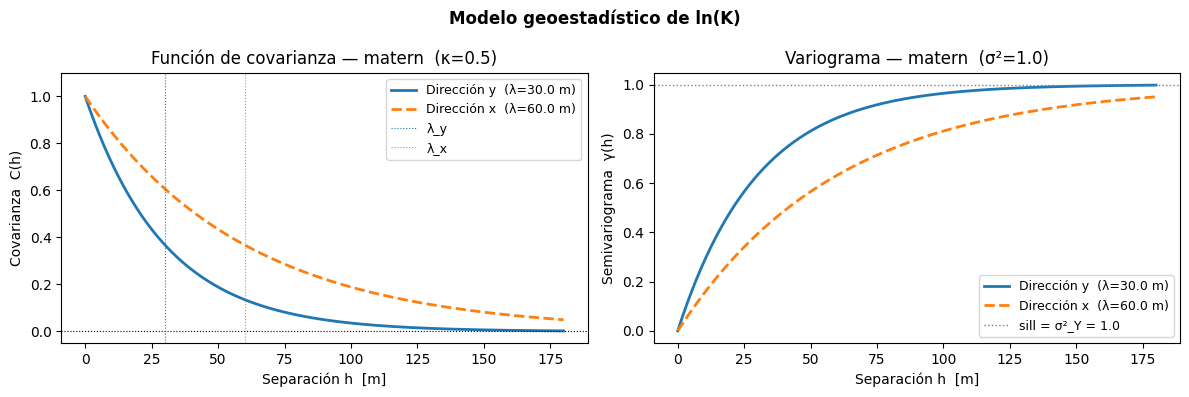

Sill (C(0))  = σ²_Y = 1.0
C(λ_y)/C(0)  = 0.368
C(λ_x)/C(0)  = 0.368


In [4]:
def cov_1d(h, variance, lam, kap, name):
    """Función de covarianza escalar 1D."""
    if name == 'matern':
        C = np.full_like(h, variance, dtype=float)
        mask = h > 0
        a = np.sqrt(2 * kap) * h[mask] / lam
        C[mask] = variance / (2**(kap-1) * sp.gamma(kap)) * a**kap * sp.kv(kap, a)
        return C
    else:  # gaussian
        return variance * np.exp(-(h / lam)**2)


# Rango de separación hasta 3× la longitud de correlación mayor
h = np.linspace(0, 3 * max(lambda_y, lambda_x), 300)

C_y = cov_1d(h, lnK_variance, lambda_y, kappa, variogram_name)
C_x = cov_1d(h, lnK_variance, lambda_x, kappa, variogram_name)
gamma_y = lnK_variance - C_y
gamma_x = lnK_variance - C_x

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Covarianza
ax = axes[0]
ax.plot(h, C_y, label=f'Dirección y  (λ={lambda_y} m)', lw=2)
ax.plot(h, C_x, label=f'Dirección x  (λ={lambda_x} m)', lw=2, ls='--')
ax.axhline(0, color='k', lw=0.8, ls=':')
ax.axvline(lambda_y, color='C0', lw=0.8, ls=':', label='λ_y')
ax.axvline(lambda_x, color='C1', lw=0.8, ls=':', label='λ_x')
ax.set_xlabel('Separación h  [m]')
ax.set_ylabel('Covarianza  C(h)')
ax.set_title(f'Función de covarianza — {variogram_name}  (κ={kappa})')
ax.legend(fontsize=9)
ax.set_ylim(-0.05 * lnK_variance, 1.1 * lnK_variance)

# Variograma
ax = axes[1]
ax.plot(h, gamma_y, label=f'Dirección y  (λ={lambda_y} m)', lw=2)
ax.plot(h, gamma_x, label=f'Dirección x  (λ={lambda_x} m)', lw=2, ls='--')
ax.axhline(lnK_variance, color='grey', lw=1, ls=':', label=f'sill = σ²_Y = {lnK_variance}')
if nugget > 0:
    ax.axhline(nugget * lnK_variance, color='red', lw=1, ls=':', label=f'nugget = {nugget}·σ²')
ax.set_xlabel('Separación h  [m]')
ax.set_ylabel('Semivariograma  γ(h)')
ax.set_title(f'Variograma — {variogram_name}  (σ²={lnK_variance})')
ax.legend(fontsize=9)

plt.suptitle('Modelo geoestadístico de ln(K)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Sill (C(0))  = σ²_Y = {lnK_variance}')
print(f'C(λ_y)/C(0)  = {cov_1d(np.array([lambda_y]), lnK_variance, lambda_y, kappa, variogram_name)[0]/lnK_variance:.3f}')
print(f'C(λ_x)/C(0)  = {cov_1d(np.array([lambda_x]), lnK_variance, lambda_x, kappa, variogram_name)[0]/lnK_variance:.3f}')

---
## 3. Una realización de ln(K) y K

Una **realización** es una instancia concreta del campo aleatorio, es decir, un campo espacial plausible de ln(K) que respeta exactamente los parámetros estadísticos especificados (media, varianza, función de covarianza).

La figura muestra **6 paneles**:

- **Fila superior (3 cortes XY horizontales):** vista en planta del campo ln(K) a tres profundidades — tope, punto medio y base del acuífero. La heterogeneidad horizontal controlada por λ_x y λ_y es visible como manchas de diferentes tamaños.

- **Sección XZ** (corte vertical a lo largo del eje x al centro del dominio en y): muestra la **estratificación vertical**. La pequeña longitud de correlación vertical λ_z = 5 m produce capas delgadas, típicas de sedimentos aluviales.

- **Sección YZ** (corte vertical a lo largo del eje y): ídem en la otra dirección.

- **K en escala logarítmica** (panel inferior derecho): la misma capa media pero mostrando K directamente. Confirma que K sigue una distribución log-normal — los valores extremos son varios órdenes de magnitud más grandes/pequeños que la media geométrica.

> Para cambiar la semilla aleatoria (`seed`) en la **Sección 1** y obtener una realización diferente con la misma estructura estadística.

Campo ln(K): shape=(60, 60, 20)  media=-3.997  std=1.017
K_geom ≈ 1.84e-02 m/s  |  rango K: [3.65e-04, 1.17e+00]


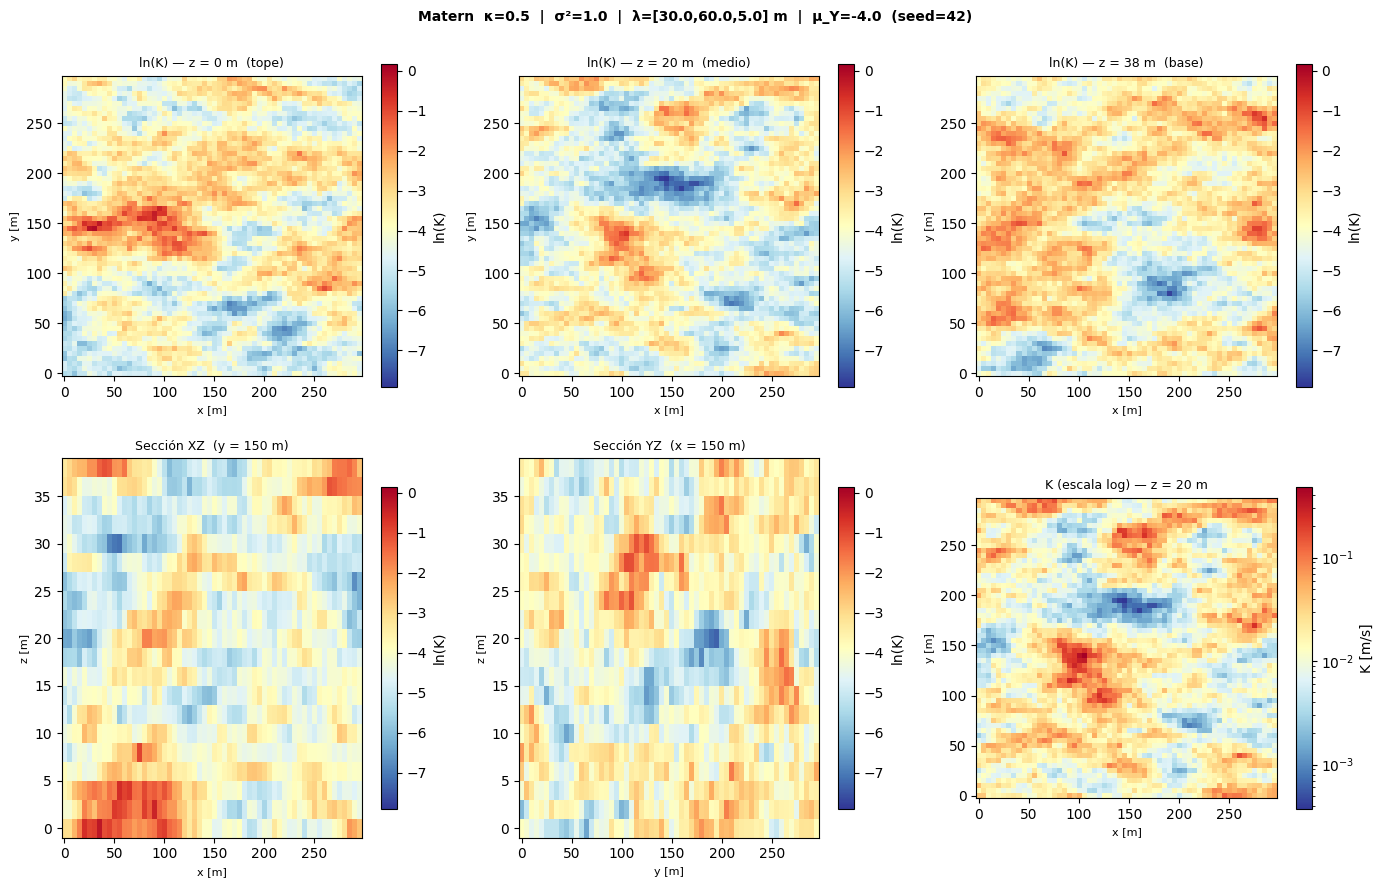

In [5]:
# ── Genera una realización 3D ─────────────────────────────────────────────────
rng        = np.random.default_rng(seed)
lnK, FFTQe = generate_randomfield(model, grid, FFTQe=FFTQe, rng=rng)
# lnK.shape == (ny, nx, nz)

print(f'Campo ln(K): shape={lnK.shape}  media={lnK.mean():.3f}  std={lnK.std():.3f}')
print(f'K_geom ≈ {np.exp(lnK.mean()):.2e} m/s  |  rango K: [{np.exp(lnK.min()):.2e}, {np.exp(lnK.max()):.2e}]')

# ── Cortes horizontales a 3 profundidades ─────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 9))

slices_z  = [iz_top, iz_mid, iz_bot]
labels_z  = [f'z = {z_vec[iz_top]:.0f} m  (tope)',
             f'z = {z_vec[iz_mid]:.0f} m  (medio)',
             f'z = {z_vec[iz_bot]:.0f} m  (base)']

vmin, vmax = lnK.min(), lnK.max()

for col, (iz, lbl) in enumerate(zip(slices_z, labels_z)):
    # Fila 0: ln(K)
    im = axes[0, col].pcolormesh(x_vec, y_vec, lnK[:, :, iz],
                                  cmap='RdYlBu_r', shading='auto',
                                  vmin=vmin, vmax=vmax)
    axes[0, col].set_title(f'ln(K) — {lbl}', fontsize=9)
    axes[0, col].set_xlabel('x [m]', fontsize=8)
    axes[0, col].set_ylabel('y [m]', fontsize=8)
    axes[0, col].set_aspect('equal')
    plt.colorbar(im, ax=axes[0, col], label='ln(K)', shrink=0.85)

# Fila 1: sección vertical XZ (corte en y central) y YZ (corte en x central)
iy_mid = n_pts_y // 2
ix_mid = n_pts_x // 2

im_xz = axes[1, 0].pcolormesh(x_vec, z_vec, lnK[iy_mid, :, :].T,
                                cmap='RdYlBu_r', shading='auto', vmin=vmin, vmax=vmax)
axes[1, 0].set_title(f'Sección XZ  (y = {y_vec[iy_mid]:.0f} m)', fontsize=9)
axes[1, 0].set_xlabel('x [m]', fontsize=8);  axes[1, 0].set_ylabel('z [m]', fontsize=8)
plt.colorbar(im_xz, ax=axes[1, 0], label='ln(K)', shrink=0.85)

im_yz = axes[1, 1].pcolormesh(y_vec, z_vec, lnK[:, ix_mid, :].T,
                                cmap='RdYlBu_r', shading='auto', vmin=vmin, vmax=vmax)
axes[1, 1].set_title(f'Sección YZ  (x = {x_vec[ix_mid]:.0f} m)', fontsize=9)
axes[1, 1].set_xlabel('y [m]', fontsize=8);  axes[1, 1].set_ylabel('z [m]', fontsize=8)
plt.colorbar(im_yz, ax=axes[1, 1], label='ln(K)', shrink=0.85)

# Panel de K en escala log (corte medio)
from matplotlib.colors import LogNorm
K_mid = np.exp(lnK[:, :, iz_mid])
im_k  = axes[1, 2].pcolormesh(x_vec, y_vec, K_mid,
                                norm=LogNorm(vmin=K_mid.min(), vmax=K_mid.max()),
                                cmap='RdYlBu_r', shading='auto')
axes[1, 2].set_title(f'K (escala log) — z = {z_vec[iz_mid]:.0f} m', fontsize=9)
axes[1, 2].set_xlabel('x [m]', fontsize=8);  axes[1, 2].set_ylabel('y [m]', fontsize=8)
axes[1, 2].set_aspect('equal')
plt.colorbar(im_k, ax=axes[1, 2], label='K [m/s]', shrink=0.85)

fig.suptitle(
    f'{variogram_name.capitalize()}  κ={kappa}  |  σ²={lnK_variance}  |'
    f'  λ=[{lambda_y},{lambda_x},{lambda_z}] m  |  μ_Y={lnK_mean:.1f}  (seed={seed})',
    fontsize=10, fontweight='bold'
)
plt.tight_layout()
plt.show()


---
## 4. Ensemble de realizaciones

### ¿Qué es un ensemble y para qué sirve?

Un **ensemble** es un conjunto de $N_r$ realizaciones independientes, todas generadas con los mismos parámetros estadísticos pero con semillas aleatorias diferentes. Cada realización representa un escenario geológico igualmente probable.

El concepto es fundamental en la **simulación de Monte Carlo estocástica**, donde:

1. Se generan $N_r$ campos K plausibles (el ensemble).
2. Se resuelve el modelo de flujo/transporte para cada campo.
3. La distribución de resultados (p.ej. concentraciones, tiempos de llegada) cuantifica la **incertidumbre** debida al desconocimiento de la heterogeneidad del acuífero.

El tamaño del ensemble debe ser suficientemente grande para que las estadísticas converjan:
- $N_r \geq 100$: estadísticas de primer y segundo orden razonables
- $N_r \geq 500$: distribuciones de probabilidad confiables
- $N_r \geq 1000$: percentiles extremos (5%, 95%) estables

### Eficiencia computacional

La FFT de la covarianza (`FFTQe`, calculada en la Sección 1) se pre-computa **una sola vez** y se reutiliza en todas las realizaciones. Esto hace que el costo de generar $N_r$ realizaciones sea aproximadamente $N_r$ veces el costo de una, en lugar de $N_r \times \mathcal{O}(N \log N)$ por separado.

La figura muestra el corte horizontal en z = z_mid de cada realización, con la misma escala de color para todas para facilitar la comparación. Nótese cómo la **estructura estadística** (tamaño de las manchas, elongación) es consistente entre realizaciones, aunque los patrones espaciales concretos son diferentes.

6 realizaciones 3D generadas  — shape de cada una: (60, 60, 20)


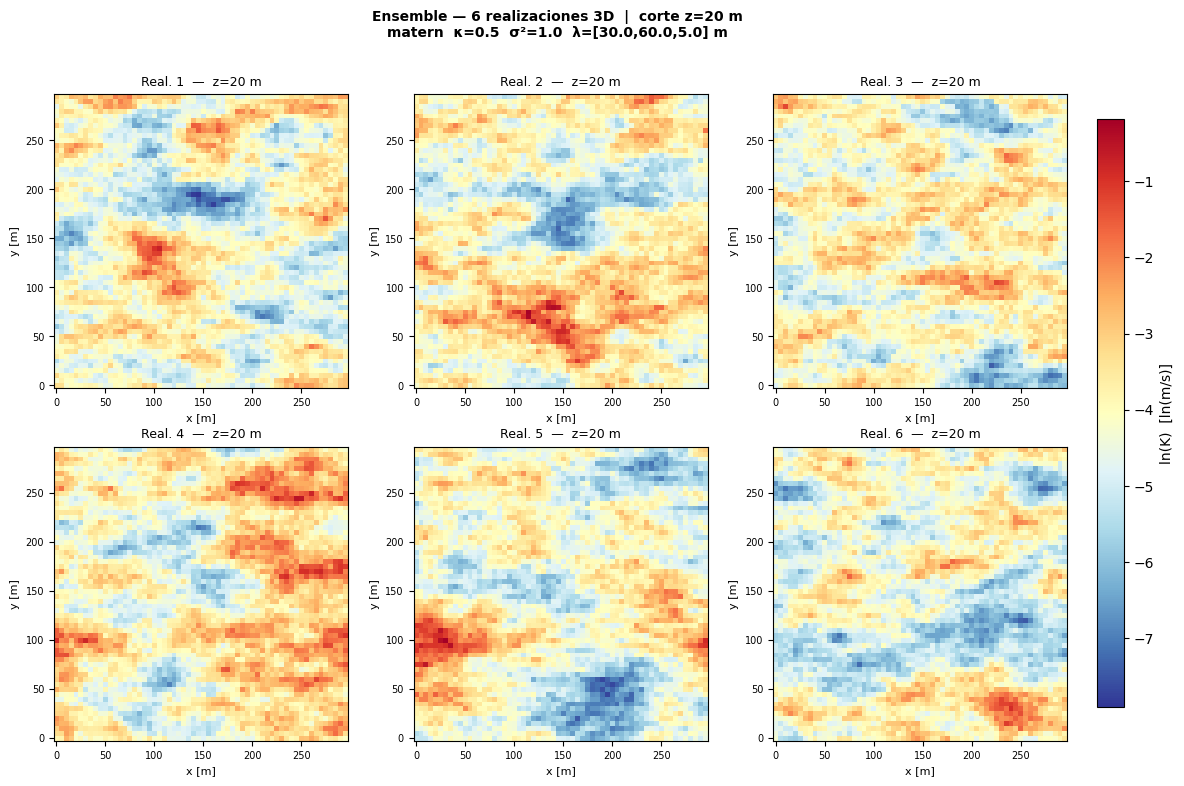

In [6]:
rng_ens = np.random.default_rng(seed)

ensemble = []
_FFTQe   = FFTQe.copy()

for i in range(n_realizations):
    lnK_i, _FFTQe = generate_randomfield(model, grid, FFTQe=_FFTQe, rng=rng_ens)
    ensemble.append(lnK_i)

print(f'{n_realizations} realizaciones 3D generadas  — shape de cada una: {ensemble[0].shape}')

# ── Mosaico: corte horizontal a z medio de cada realización ───────────────────
ncols = min(n_realizations, 3)
nrows = int(np.ceil(n_realizations / ncols))

vmin_g = min(f[:, :, iz_mid].min() for f in ensemble)
vmax_g = max(f[:, :, iz_mid].max() for f in ensemble)

fig, axes = plt.subplots(nrows, ncols,
                          figsize=(4.5 * ncols, 4.2 * nrows),
                          squeeze=False)

for idx, ax in enumerate(axes.flat):
    if idx < n_realizations:
        im = ax.pcolormesh(x_vec, y_vec, ensemble[idx][:, :, iz_mid],
                           cmap='RdYlBu_r', shading='auto',
                           vmin=vmin_g, vmax=vmax_g)
        ax.set_title(f'Real. {idx+1}  —  z={z_vec[iz_mid]:.0f} m', fontsize=9)
        ax.set_aspect('equal')
        ax.set_xlabel('x [m]', fontsize=8);  ax.set_ylabel('y [m]', fontsize=8)
        ax.tick_params(labelsize=7)
    else:
        ax.set_visible(False)

fig.subplots_adjust(right=0.88)
cax = fig.add_axes([0.90, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cax, label='ln(K)  [ln(m/s)]')

fig.suptitle(
    f'Ensemble — {n_realizations} realizaciones 3D  |  corte z={z_vec[iz_mid]:.0f} m\n'
    f'{variogram_name}  κ={kappa}  σ²={lnK_variance}  λ=[{lambda_y},{lambda_x},{lambda_z}] m',
    fontsize=10, fontweight='bold'
)
plt.show()

---
## 5. Estadísticas del ensemble

### ¿Qué nos dicen las estadísticas del ensemble?

Las estadísticas calculadas pixel a pixel sobre el ensemble son estimadores de los **momentos del proceso estocástico** $Y(\mathbf{x})$:

**Media del ensemble** $\hat{\mu}_Y(\mathbf{x})$:

$$\hat{\mu}_Y(\mathbf{x}) = \frac{1}{N_r}\sum_{i=1}^{N_r} Y^{(i)}(\mathbf{x}) \;\xrightarrow{N_r \to \infty}\; \mu_Y$$

Idealmente debería ser **espacialmente uniforme** e igual a `lnK_mean`. Desviaciones de la uniformidad con ensembles pequeños son esperables (fluctuaciones de muestreo).

**Varianza del ensemble** $\hat{\sigma}^2_Y(\mathbf{x})$:

$$\hat{\sigma}^2_Y(\mathbf{x}) = \frac{1}{N_r}\sum_{i=1}^{N_r} \left(Y^{(i)}(\mathbf{x}) - \hat{\mu}_Y(\mathbf{x})\right)^2 \;\xrightarrow{N_r \to \infty}\; \sigma^2_Y$$

Debería converger a `lnK_variance`. La varianza tiende a subestimarse con ensembles pequeños.

**Distribución marginal:** el histograma de todos los valores del ensemble debe seguir una distribución normal $\mathcal{N}(\mu_Y, \sigma^2_Y)$, verificando que el generador produce la distribución correcta.

> Con pocos realizaciones ($N_r < 20$) las estadísticas tienen alta incertidumbre de muestreo. Para verificaciones formales se recomienda $N_r \geq 100$.

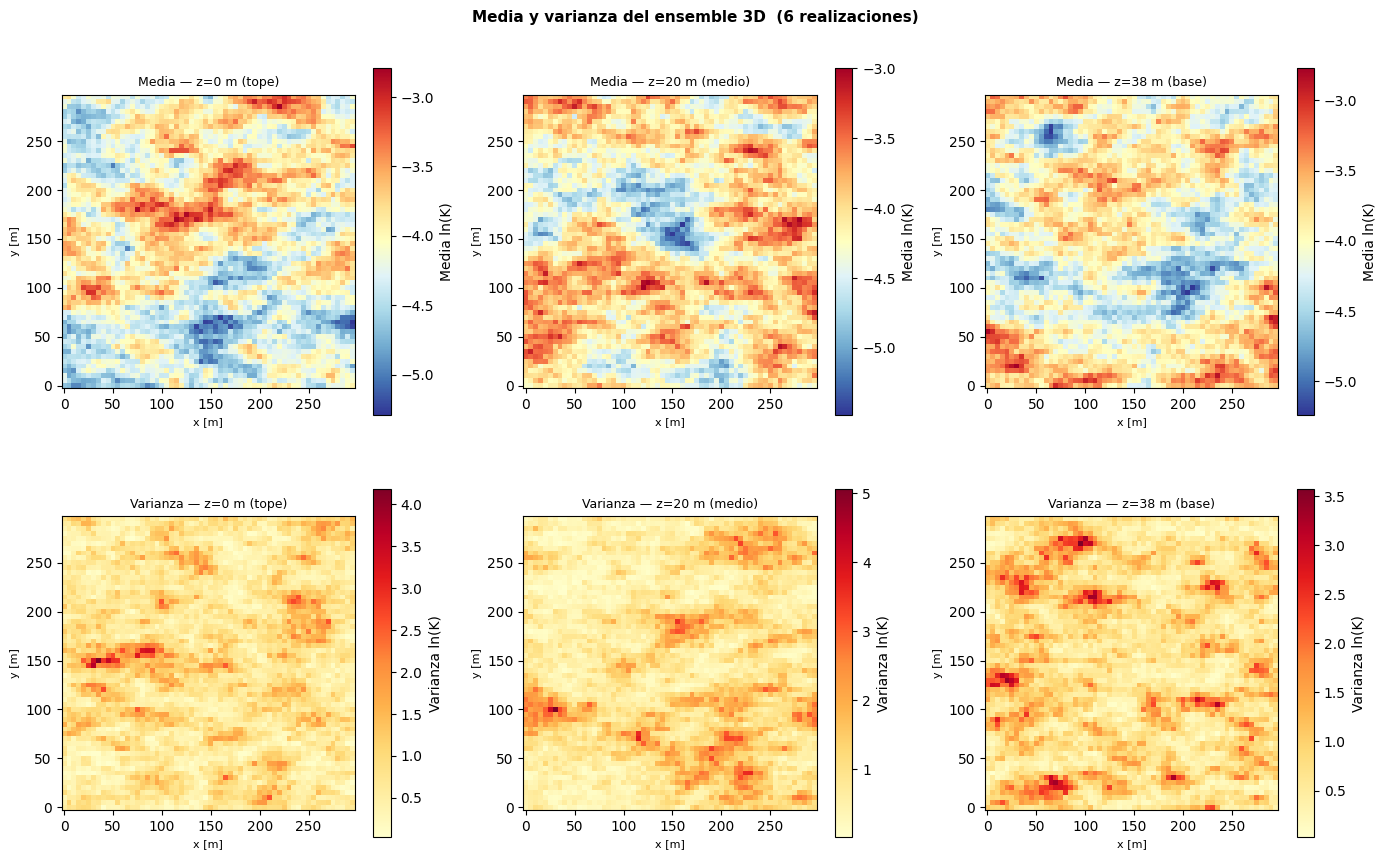

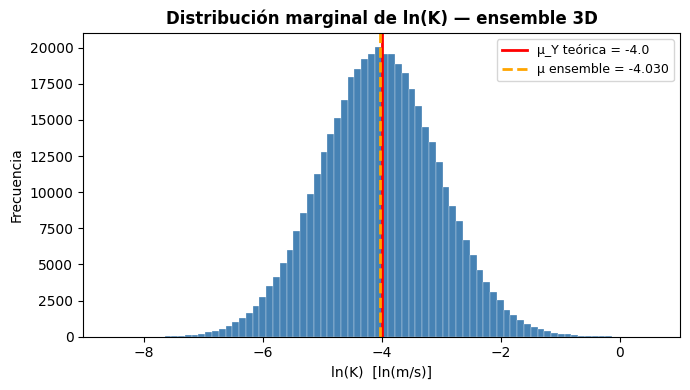

─── Estadísticas globales del ensemble ────────────────────────────────
  μ_Y    = -4.0303   (objetivo: -4.0)
  σ²_Y   = 0.9837    (objetivo: 1.0)
  Rango  = [-8.570, 0.561]
  K_geom = 1.777e-02 m/s


In [7]:
ens_array = np.stack(ensemble, axis=0)   # shape (n_real, ny, nx, nz)
ens_mean  = ens_array.mean(axis=0)
ens_var   = ens_array.var(axis=0)

fig, axes = plt.subplots(2, 3, figsize=(14, 9))

titles_z = [f'z={z_vec[iz_top]:.0f} m (tope)',
            f'z={z_vec[iz_mid]:.0f} m (medio)',
            f'z={z_vec[iz_bot]:.0f} m (base)']

for col, (iz, tit) in enumerate(zip([iz_top, iz_mid, iz_bot], titles_z)):
    im0 = axes[0, col].pcolormesh(x_vec, y_vec, ens_mean[:, :, iz],
                                   cmap='RdYlBu_r', shading='auto')
    plt.colorbar(im0, ax=axes[0, col], label='Media ln(K)', shrink=0.85)
    axes[0, col].set_title(f'Media — {tit}', fontsize=9)
    axes[0, col].set_xlabel('x [m]', fontsize=8);  axes[0, col].set_ylabel('y [m]', fontsize=8)
    axes[0, col].set_aspect('equal')

    im1 = axes[1, col].pcolormesh(x_vec, y_vec, ens_var[:, :, iz],
                                   cmap='YlOrRd', shading='auto')
    plt.colorbar(im1, ax=axes[1, col], label='Varianza ln(K)', shrink=0.85)
    axes[1, col].set_title(f'Varianza — {tit}', fontsize=9)
    axes[1, col].set_xlabel('x [m]', fontsize=8);  axes[1, col].set_ylabel('y [m]', fontsize=8)
    axes[1, col].set_aspect('equal')

fig.suptitle(
    f'Media y varianza del ensemble 3D  ({n_realizations} realizaciones)',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.show()

# ── Histograma marginal ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(ens_array.ravel(), bins=80, color='steelblue', edgecolor='white', lw=0.2)
ax.axvline(lnK_mean,         color='red',    lw=2, label=f'μ_Y teórica = {lnK_mean}')
ax.axvline(ens_array.mean(), color='orange', lw=2, ls='--',
           label=f'μ ensemble = {ens_array.mean():.3f}')
ax.set_xlabel('ln(K)  [ln(m/s)]');  ax.set_ylabel('Frecuencia')
ax.set_title('Distribución marginal de ln(K) — ensemble 3D', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print('─── Estadísticas globales del ensemble ────────────────────────────────')
print(f'  μ_Y    = {ens_array.mean():.4f}   (objetivo: {lnK_mean})')
print(f'  σ²_Y   = {ens_array.var():.4f}    (objetivo: {lnK_variance})')
print(f'  Rango  = [{ens_array.min():.3f}, {ens_array.max():.3f}]')
print(f'  K_geom = {np.exp(ens_array.mean()):.3e} m/s')


---
## 6. Generación y guardado de N realizaciones

### Formato de archivo: `.npz` (NumPy comprimido)

Las realizaciones se guardan en formato **`.npz`**, que es el formato nativo de NumPy para guardar múltiples arrays con compresión. Es la opción más eficiente para intercambio entre scripts Python.

**Contenido del archivo:**

| Clave | Tipo | Shape | Descripción |
|-------|------|-------|-------------|
| `lnK_ensemble` | float64 | `(N, ny+1, nx+1, nz+1)` | Campos ln(K) [ln(m/s)] |
| `K_ensemble` | float64 | `(N, ny+1, nx+1, nz+1)` | K = exp(lnK) [m/s] |
| `y_vec` | float64 | `(ny+1,)` | Coordenadas y [m] |
| `x_vec` | float64 | `(nx+1,)` | Coordenadas x [m] |
| `z_vec` | float64 | `(nz+1,)` | Coordenadas z [m] |
| `params` | float64 | `(16,)` | Parámetros del variograma* |

*Orden de `params`: `[lnK_mean, lnK_variance, lambda_y, lambda_x, lambda_z, kappa, nugget, micro, flag_zh, n_pts_y, n_pts_x, n_pts_z, d_pts_y, d_pts_x, d_pts_z, seed]`

**Cómo cargar el archivo en otro script:**

```python
import numpy as np

data    = np.load('Kfields_output/Kfield_3D_N5_YYYYMMDD_HHMMSS.npz')
lnK_ens = data['lnK_ensemble']   # shape (N, ny+1, nx+1, nz+1)
K_ens   = data['K_ensemble']
x_vec   = data['x_vec']
y_vec   = data['y_vec']
z_vec   = data['z_vec']

# Acceder a la realización i, capa z=0:
lnK_i_capa0 = lnK_ens[i, :, :, 0]
```

### Parámetros configurables en esta sección

- **`N_save`**: cuántas realizaciones generar. Independiente del ensemble de visualización (secciones 4–5).
- **`save_dir`**: carpeta de destino. Se crea automáticamente si no existe.
- **`save_seed`**: semilla independiente para reproducibilidad del ensemble guardado.
- **`file_prefix`**: prefijo del nombre del archivo. El nombre final incluye N y timestamp para evitar sobreescrituras.

Generando 5 realizaciones 3D...
  [1/5]  shape=(60, 60, 20)  media=-4.079  std=0.974
  [2/5]  shape=(60, 60, 20)  media=-4.092  std=0.963
  [3/5]  shape=(60, 60, 20)  media=-4.130  std=0.989
  [4/5]  shape=(60, 60, 20)  media=-4.085  std=0.995
  [5/5]  shape=(60, 60, 20)  media=-3.942  std=0.998

Archivo guardado:
  Ruta    : /home/abelardo/UNAM/Conversion/Paper_4_k10/RRWPT_Python/Kfields_output/Kfield_3D_N5_20260516_153437.npz
  Nombre  : Kfield_3D_N5_20260516_153437.npz
  Tamaño  : 5.43 MB
  Arrays  : lnK_ensemble (5, 60, 60, 20)  |  K_ensemble (5, 60, 60, 20)

Verificación de carga:
  Claves disponibles : ['lnK_ensemble', 'K_ensemble', 'y_vec', 'x_vec', 'z_vec', 'params']


  lnK_ensemble shape : (5, 60, 60, 20)
  K_ensemble   shape : (5, 60, 60, 20)
  Ejemplo carga      : lnK_ens = np.load("./Kfields_output/Kfield_3D_N5_20260516_153437.npz")["lnK_ensemble"]


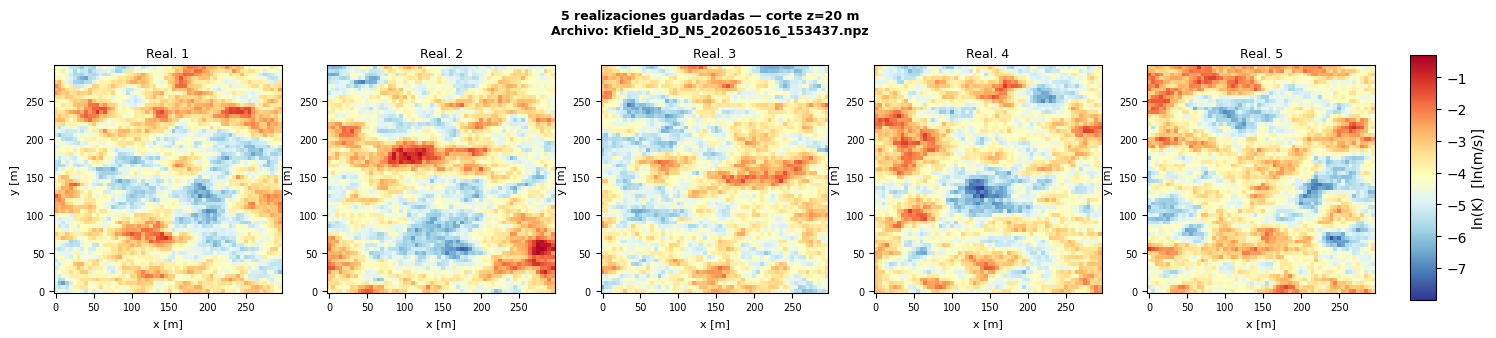

In [8]:
import os, datetime

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║   PARÁMETROS DE GUARDADO — modifica aquí                                   ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

N_save      = 5                    # número de realizaciones a generar y guardar
save_dir    = './Kfields_output'   # carpeta de salida (se crea si no existe)
save_seed   = 100                  # semilla para reproducibilidad
file_prefix = 'Kfield_3D'         # prefijo del nombre del archivo

# ══════════════════════════════════════════════════════════════════════════════

os.makedirs(save_dir, exist_ok=True)

rng_save   = np.random.default_rng(save_seed)
_FFTQe_sv  = FFTQe.copy()

lnK_list = []
print(f'Generando {N_save} realizaciones 3D...')

for i in range(N_save):
    lnK_i, _FFTQe_sv = generate_randomfield(model, grid, FFTQe=_FFTQe_sv, rng=rng_save)
    lnK_list.append(lnK_i)
    print(f'  [{i+1}/{N_save}]  shape={lnK_i.shape}  '
          f'media={lnK_i.mean():.3f}  std={lnK_i.std():.3f}')

lnK_ens = np.stack(lnK_list, axis=0)   # (N_save, ny+1, nx+1, nz+1)
K_ens   = np.exp(lnK_ens)

# ── Guardar ───────────────────────────────────────────────────────────────────
timestamp = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
filename  = f'{file_prefix}_N{N_save}_{timestamp}.npz'
filepath  = os.path.join(save_dir, filename)

np.savez_compressed(
    filepath,
    lnK_ensemble = lnK_ens,          # ln(K) — shape (N, ny+1, nx+1, nz+1)
    K_ensemble   = K_ens,            # K [m/s] — shape (N, ny+1, nx+1, nz+1)
    y_vec        = y_vec,            # coordenadas y [m]
    x_vec        = x_vec,            # coordenadas x [m]
    z_vec        = z_vec,            # coordenadas z [m]
    # metadatos del variograma (recuperables al cargar)
    params       = np.array([
        lnK_mean, lnK_variance,
        lambda_y, lambda_x, lambda_z,
        kappa, nugget, micro, flag_zh,
        n_pts_y, n_pts_x, n_pts_z,
        d_pts_y, d_pts_x, d_pts_z,
        float(save_seed)
    ])
)

size_mb = os.path.getsize(filepath) / 1e6
print(f'\nArchivo guardado:')
print(f'  Ruta    : {os.path.abspath(filepath)}')
print(f'  Nombre  : {filename}')
print(f'  Tamaño  : {size_mb:.2f} MB')
print(f'  Arrays  : lnK_ensemble {lnK_ens.shape}  |  K_ensemble {K_ens.shape}')

# ── Verificar carga ───────────────────────────────────────────────────────────
data = np.load(filepath)
print(f'\nVerificación de carga:')
print(f'  Claves disponibles : {list(data.keys())}')
print(f'  lnK_ensemble shape : {data["lnK_ensemble"].shape}')
print(f'  K_ensemble   shape : {data["K_ensemble"].shape}')
print(f'  Ejemplo carga      : lnK_ens = np.load("{filepath}")["lnK_ensemble"]')

# ── Vista rápida de las 5 realizaciones guardadas ─────────────────────────────
fig, axes = plt.subplots(1, N_save, figsize=(3.5 * N_save, 3.5))
if N_save == 1:
    axes = [axes]

vmin_sv = lnK_ens[:, :, :, iz_mid].min()
vmax_sv = lnK_ens[:, :, :, iz_mid].max()

for i, ax in enumerate(axes):
    im = ax.pcolormesh(x_vec, y_vec, lnK_ens[i, :, :, iz_mid],
                       cmap='RdYlBu_r', shading='auto',
                       vmin=vmin_sv, vmax=vmax_sv)
    ax.set_title(f'Real. {i+1}', fontsize=9)
    ax.set_aspect('equal')
    ax.set_xlabel('x [m]', fontsize=8);  ax.set_ylabel('y [m]', fontsize=8)
    ax.tick_params(labelsize=7)

fig.subplots_adjust(right=0.88)
cax = fig.add_axes([0.90, 0.15, 0.015, 0.7])
fig.colorbar(im, cax=cax, label='ln(K)  [ln(m/s)]')
fig.suptitle(
    f'{N_save} realizaciones guardadas — corte z={z_vec[iz_mid]:.0f} m\n'
    f'Archivo: {filename}',
    fontsize=9, fontweight='bold'
)
plt.show()